# T5 Thesis Experiment Notebook

This notebook trains and evaluates a **T5** model for Mauritian Creole text restoration:

- Orthographic text normalization
- Punctuation restoration
- Capitalization restoration

It follows the same experiment logic as the ByT5 notebook so results can later be compared with **ByT5**, **Qwen**, and **BiLSTM**.

This notebook saves:

- Training time
- Inference time
- Train / validation / test metrics
- Overfitting plots
- Predictions
- Error analysis
- T5-specific SentencePiece tokenization analysis
- Orthographic variation recovery analysis
- Emoji/symbol subset analysis
- Synthetic noise robustness analysis

## 1. Install libraries

Run this once on RunPod if needed.

In [1]:
# Uncomment this cell on RunPod if needed.
# %pip install -U transformers datasets accelerate sentencepiece sacrebleu jiwer scikit-learn pandas numpy matplotlib tqdm

## 2. Imports

In [2]:
import os
import re
import json
import time
import random
import platform
import warnings
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Any
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from datasets import Dataset as HFDataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed,
)

from jiwer import wer, cer
from sacrebleu.metrics import CHRF
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from IPython.display import display

warnings.filterwarnings("ignore")

## 3. Configuration

Edit this cell before running.

For T5, the task prefix is important because T5 frames tasks as text-to-text generation.

In [3]:
EXPERIMENT_NAME = "t5_mauritian_creole_text_restoration"
MODEL_NAME = "google-t5/t5-small" 

# T5-specific task prefix. Keep it consistent across train/validation/test.
TASK_PREFIX = "restore Mauritian Creole text: "

# Paths to train-val-test data
TRAIN_PATH = "/workspace/mauritian_creole_nlp/data/dataset_split/train.json"
VAL_PATH   = "/workspace/mauritian_creole_nlp/data/dataset_split/val.json"
TEST_PATH  = "/workspace/mauritian_creole_nlp/data/dataset_split/test.json"

# Columns in JSON files
INPUT_COL = "text"
TARGET_COL = "standardized"

OUTPUT_DIR = Path("results_v3") / "t5"
for sub in ["plots", "predictions", "analysis", "checkpoints"]:
    (OUTPUT_DIR / sub).mkdir(parents=True, exist_ok=True)

SEED = 18
MAX_INPUT_LENGTH = 256
MAX_TARGET_LENGTH = 256
NUM_EPOCHS = 8
LEARNING_RATE = 3e-4
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 2
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.05
GENERATION_MAX_LENGTH = 256
NUM_BEAMS = 4

# Set to 500 for quick testing; use None for final thesis run.
EVAL_SAMPLE_LIMIT = None

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
USE_FP16 = torch.cuda.is_available() and not USE_BF16

## 4. Environment and GPU information

In [4]:
def get_environment_info() -> Dict[str, Any]:
    info = {
        "experiment_name": EXPERIMENT_NAME,
        "timestamp": datetime.now().isoformat(),
        "python_version": platform.python_version(),
        "platform": platform.platform(),
        "pytorch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "model_name": MODEL_NAME,
        "task_prefix": TASK_PREFIX,
        "seed": SEED,
        "bf16_enabled": USE_BF16,
        "fp16_enabled": USE_FP16,
    }
    if torch.cuda.is_available():
        info.update({
            "gpu_name": torch.cuda.get_device_name(0),
            "gpu_count": torch.cuda.device_count(),
            "gpu_capability": str(torch.cuda.get_device_capability(0)),
        })
    return info

env_info = get_environment_info()
print(json.dumps(env_info, indent=2))
with open(OUTPUT_DIR / "environment_info.json", "w", encoding="utf-8") as f:
    json.dump(env_info, f, indent=2, ensure_ascii=False)

{
  "experiment_name": "t5_mauritian_creole_text_restoration",
  "timestamp": "2026-08-03T17:45:18.371956",
  "python_version": "3.12.3",
  "platform": "Linux-6.8.0-134-generic-x86_64-with-glibc2.39",
  "pytorch_version": "2.8.0+cu128",
  "cuda_available": true,
  "cuda_version": "12.8",
  "model_name": "google-t5/t5-small",
  "task_prefix": "restore Mauritian Creole text: ",
  "seed": 18,
  "bf16_enabled": true,
  "fp16_enabled": false,
  "gpu_name": "NVIDIA GeForce RTX 4090",
  "gpu_count": 1,
  "gpu_capability": "(8, 9)"
}


## 5. Load train, validation, and test data

In [5]:
def load_json(path: str, split_name: str) -> pd.DataFrame:
    path_obj = Path(path)

    if not path_obj.exists():
        raise FileNotFoundError(
            f"Missing {split_name} file: {path}. Update the path in the configuration cell."
        )

    # Load JSON file
    with open(path_obj, "r", encoding="utf-8") as f:
        data = json.load(f)

    df = pd.DataFrame(data)

    # Check required columns
    if INPUT_COL not in df.columns or TARGET_COL not in df.columns:
        raise ValueError(
            f"{split_name} must contain {INPUT_COL!r} and {TARGET_COL!r}. "
            f"Found: {list(df.columns)}"
        )

    # Keep only required columns
    df = df[[INPUT_COL, TARGET_COL]].copy()

    # Handle missing values
    df[INPUT_COL] = df[INPUT_COL].fillna("").astype(str)
    df[TARGET_COL] = df[TARGET_COL].fillna("").astype(str)

    # Remove empty samples
    df = df[
        (df[INPUT_COL].str.strip() != "") &
        (df[TARGET_COL].str.strip() != "")
    ].reset_index(drop=True)

    # Add split identifier
    df["split"] = split_name

    return df


train_df = load_json(TRAIN_PATH, "train")
val_df = load_json(VAL_PATH, "validation")
test_df = load_json(TEST_PATH, "test")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

display(train_df.head())

Train: (11064, 3)
Validation: (1383, 3)
Test: (1383, 3)


,text,standardized,split
0,La dan zenfant ki victime femme bizin pran con...,Ladan zanfan ki victime femme bizin pran kont ...,train
1,Or believe li couyoun li kit so parliamentary ...,Or believe li kuyon. Li kite so parliamentary ...,train
2,Apres zot dire ena soldat dan moris. Mo sire v...,Apre zot dire ena soldat dan Moris. Mo sir vac...,train
3,Et voilà c’est reparti avec bann intellectuel ...,Et voilà. Se reparti avec bann intellectuel fa...,train
4,Wadir dan film,Wadire dan film.,train


## 6. Dataset statistics

In [6]:
def basic_text_stats(df: pd.DataFrame, text_col: str, split_name: str) -> Dict[str, Any]:
    texts = df[text_col].astype(str).tolist()
    words = [w for t in texts for w in t.split()]
    chars = [ch for t in texts for ch in t]
    return {
        "split": split_name,
        "column": text_col,
        "num_rows": len(df),
        "num_words": len(words),
        "word_vocab_size": len(set(words)),
        "num_characters": len(chars),
        "character_vocab_size": len(set(chars)),
        "avg_words_per_sentence": float(np.mean([len(t.split()) for t in texts])) if texts else 0,
        "avg_chars_per_sentence": float(np.mean([len(t) for t in texts])) if texts else 0,
        "max_chars_sentence": int(max([len(t) for t in texts], default=0)),
    }

stats_rows = []
for split_name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    stats_rows.append(basic_text_stats(df, INPUT_COL, split_name))
    stats_rows.append(basic_text_stats(df, TARGET_COL, split_name))

stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv(OUTPUT_DIR / "dataset_statistics.csv", index=False, encoding="utf-8")
display(stats_df)

,split,column,num_rows,num_words,word_vocab_size,num_characters,character_vocab_size,avg_words_per_sentence,avg_chars_per_sentence,max_chars_sentence
0,train,text,11064,195282,25124,1000800,392,17.650217,90.455531,1261
1,train,standardized,11064,193408,21436,1012864,366,17.480839,91.545915,1246
2,validation,text,1383,24611,6764,126035,211,17.795372,91.131598,1073
3,validation,standardized,1383,24351,5982,127555,206,17.607375,92.230658,1053
4,test,text,1383,24784,6822,126139,257,17.920463,91.206797,1123
5,test,standardized,1383,24512,6143,127598,249,17.723789,92.261750,1183


## 7. Load T5 tokenizer and model

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

if torch.cuda.is_available():
    model = model.to("cuda")

print("Tokenizer:", tokenizer.__class__.__name__)
print("Model:", model.__class__.__name__)
print("Vocabulary size:", len(tokenizer))
print("Pad token:", tokenizer.pad_token, tokenizer.pad_token_id)
print("EOS token:", tokenizer.eos_token, tokenizer.eos_token_id)
print("UNK token:", tokenizer.unk_token, tokenizer.unk_token_id)
print("Device:", next(model.parameters()).device)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Tokenizer: T5Tokenizer
Model: T5ForConditionalGeneration
Vocabulary size: 32100
Pad token: <pad> 0
EOS token: </s> 1
UNK token: <unk> 2
Device: cuda:0


## 8. T5-specific tokenization analysis

Unlike ByT5, T5 uses SentencePiece-style subword tokenization. This section analyzes token length, token-to-word ratio, unknown-token rate, and token examples.

In [8]:
def add_task_prefix(text: str) -> str:
    return TASK_PREFIX + str(text)

def tokenize_to_tokens(text: str) -> List[str]:
    return tokenizer.tokenize(str(text))

def token_ids(text: str) -> List[int]:
    return tokenizer(str(text), add_special_tokens=True)["input_ids"]

def add_t5_token_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["prefixed_input"] = out[INPUT_COL].apply(add_task_prefix)
    out["input_word_len"] = out[INPUT_COL].apply(lambda x: len(str(x).split()))
    out["target_word_len"] = out[TARGET_COL].apply(lambda x: len(str(x).split()))
    out["input_char_len"] = out[INPUT_COL].apply(lambda x: len(str(x)))
    out["target_char_len"] = out[TARGET_COL].apply(lambda x: len(str(x)))
    out["prefixed_input_token_len"] = out["prefixed_input"].apply(lambda x: len(tokenizer(x, add_special_tokens=True)["input_ids"]))
    out["target_token_len"] = out[TARGET_COL].apply(lambda x: len(tokenizer(str(x), add_special_tokens=True)["input_ids"]))
    out["input_token_word_ratio"] = out["prefixed_input_token_len"] / out["input_word_len"].replace(0, np.nan)
    out["target_token_word_ratio"] = out["target_token_len"] / out["target_word_len"].replace(0, np.nan)
    out["input_has_unk"] = out["prefixed_input"].apply(lambda x: tokenizer.unk_token_id in token_ids(x))
    out["target_has_unk"] = out[TARGET_COL].apply(lambda x: tokenizer.unk_token_id in token_ids(str(x)))
    out["input_truncated"] = out["prefixed_input_token_len"] > MAX_INPUT_LENGTH
    out["target_truncated"] = out["target_token_len"] > MAX_TARGET_LENGTH
    return out

tok_train = add_t5_token_features(train_df)
tok_val = add_t5_token_features(val_df)
tok_test = add_t5_token_features(test_df)
tok_all = pd.concat([tok_train, tok_val, tok_test], ignore_index=True)

token_summary = tok_all.groupby("split")[[
    "input_word_len", "target_word_len", "input_char_len", "target_char_len",
    "prefixed_input_token_len", "target_token_len", "input_token_word_ratio", "target_token_word_ratio",
    "input_has_unk", "target_has_unk", "input_truncated", "target_truncated"
]].agg(["mean", "median", "min", "max"]).round(3)

tok_all.to_csv(OUTPUT_DIR / "analysis" / "t5_token_features_all_splits.csv", index=False, encoding="utf-8")
token_summary.to_csv(OUTPUT_DIR / "analysis" / "t5_token_summary.csv", encoding="utf-8")
display(token_summary)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (555 > 512). Running this sequence through the model will result in indexing errors


input_word_len                 target_word_len                  \
                     mean median min  max            mean median min  max   
split                                                                       
test               17.920   12.0   1  227          17.724   12.0   1  227   
train              17.650   12.0   1  231          17.481   12.0   1  230   
validation         17.795   12.0   1  207          17.607   12.0   1  208   

           input_char_len         ... target_has_unk       input_truncated  \
                     mean median  ...            min   max            mean   
split                             ...                                        
test               91.207   62.0  ...          False  True           0.007   
train              90.456   62.0  ...          False  True           0.005   
validation         91.132   62.0  ...          False  True           0.004   

                               target_truncated                      
           median    min   max             mean median    min   max  
split                                                                
test          0.0  False  True            0.006    0.0  False  True  
train         0.0  False  True            0.004    0.0  False  True  
validation    0.0  False  True            0.003    0.0  False  True  

[3 rows x 48 columns]

## 9. Plot T5 token-length distribution

findfont: Failed to find font weight semibold, now using 700.


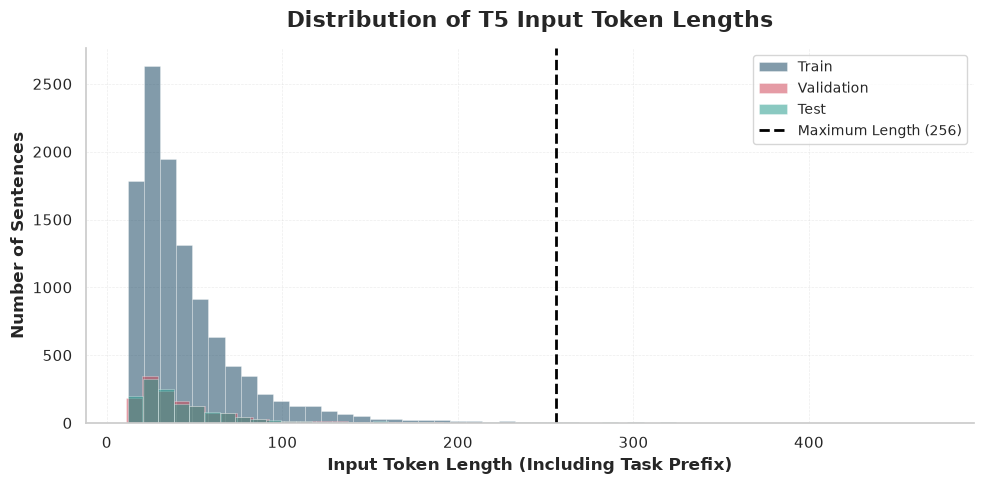

In [9]:
def plot_input_token_length_distribution(tok_train, tok_val, tok_test):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5))

    colors = {
        "train": "#1B4965",        # deep blue
        "validation": "#D1495B",  # muted red
        "test": "#2A9D8F"         # teal
    }

    for split_name, df in [
        ("train", tok_train),
        ("validation", tok_val),
        ("test", tok_test),
    ]:
        plt.hist(
            df["prefixed_input_token_len"],
            bins=50,
            alpha=0.55,
            color=colors[split_name],
            edgecolor="white",
            linewidth=0.4,
            label=split_name.capitalize()
        )

    plt.axvline(
        MAX_INPUT_LENGTH,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Maximum Length ({MAX_INPUT_LENGTH})"
    )

    plt.title(
        "Distribution of T5 Input Token Lengths",
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    plt.xlabel(
        "Input Token Length (Including Task Prefix)",
        fontsize=12,
        fontweight="semibold"
    )

    plt.ylabel(
        "Number of Sentences",
        fontsize=12,
        fontweight="semibold"
    )

    plt.grid(
        linestyle="--",
        linewidth=0.5,
        alpha=0.35
    )

    plt.legend(
        frameon=True,
        fancybox=True,
        fontsize=10,
        loc="best"
    )

    sns.despine()
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "plots" / "t5_input_token_length_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


plot_input_token_length_distribution(tok_train, tok_val, tok_test)

## 10. T5 tokenization examples

In [10]:
def show_t5_tokenization_examples(df: pd.DataFrame, n: int = 5) -> pd.DataFrame:
    examples = df.sample(min(n, len(df)), random_state=SEED).copy()
    rows = []
    for _, row in examples.iterrows():
        raw_text = row[INPUT_COL]
        prefixed_text = add_task_prefix(raw_text)
        tokens = tokenize_to_tokens(prefixed_text)
        ids = token_ids(prefixed_text)
        rows.append({
            "raw_input": raw_text,
            "prefixed_input": prefixed_text,
            "tokens": tokens,
            "token_ids": ids,
            "num_tokens": len(ids),
            "num_words_raw": len(str(raw_text).split()),
            "token_word_ratio": len(ids) / max(len(str(raw_text).split()), 1),
            "contains_unk": tokenizer.unk_token_id in ids,
        })
    return pd.DataFrame(rows)

token_examples_df = show_t5_tokenization_examples(train_df, n=8)
token_examples_df.to_csv(OUTPUT_DIR / "analysis" / "t5_tokenization_examples.csv", index=False, encoding="utf-8")
display(token_examples_df)

,raw_input,prefixed_input,tokens,token_ids,num_tokens,num_words_raw,token_word_ratio,contains_unk
0,Cyclone vin zis dan weekend ceki pli comik la ...,restore Mauritian Creole text: Cyclone vin zis...,"[▁restore, ▁Ma, uri, tian, ▁Cre, o, le, ▁text,...","[7882, 1534, 459, 12572, 5895, 32, 109, 1499, ...",84,35,2.400000,True
1,Fime simik encr,restore Mauritian Creole text: Fime simik encr,"[▁restore, ▁Ma, uri, tian, ▁Cre, o, le, ▁text,...","[7882, 1534, 459, 12572, 5895, 32, 109, 1499, ...",18,3,6.000000,False
2,fer 3ans mo madam travail ssr airport every da...,restore Mauritian Creole text: fer 3ans mo mad...,"[▁restore, ▁Ma, uri, tian, ▁Cre, o, le, ▁text,...","[7882, 1534, 459, 12572, 5895, 32, 109, 1499, ...",35,18,1.944444,False
3,Sa oui minis please gete ki kapave fr pu nu ba...,restore Mauritian Creole text: Sa oui minis pl...,"[▁restore, ▁Ma, uri, tian, ▁Cre, o, le, ▁text,...","[7882, 1534, 459, 12572, 5895, 32, 109, 1499, ...",92,44,2.090909,False
4,Partout pareil Abu du pouvoir who cares for karma,restore Mauritian Creole text: Partout pareil ...,"[▁restore, ▁Ma, uri, tian, ▁Cre, o, le, ▁text,...","[7882, 1534, 459, 12572, 5895, 32, 109, 1499, ...",24,9,2.666667,False
5,Pena date narien kisanla ine posté sa svp quan...,restore Mauritian Creole text: Pena date narie...,"[▁restore, ▁Ma, uri, tian, ▁Cre, o, le, ▁text,...","[7882, 1534, 459, 12572, 5895, 32, 109, 1499, ...",43,12,3.583333,False
6,Noune ariv 2026 ena enkor p croir dan per noel...,restore Mauritian Creole text: Noune ariv 2026...,"[▁restore, ▁Ma, uri, tian, ▁Cre, o, le, ▁text,...","[7882, 1534, 459, 12572, 5895, 32, 109, 1499, ...",97,39,2.487179,False
7,Cote sa bouge ceki visite lopital minuit la ce...,restore Mauritian Creole text: Cote sa bouge c...,"[▁restore, ▁Ma, uri, tian, ▁Cre, o, le, ▁text,...","[7882, 1534, 459, 12572, 5895, 32, 109, 1499, ...",36,15,2.400000,False


## 11. Most frequent T5 tokens in the training input

In [11]:
def most_common_t5_tokens(df: pd.DataFrame, text_col: str, top_n: int = 50) -> pd.DataFrame:
    counter = Counter()
    for text in df[text_col].astype(str).tolist():
        counter.update(tokenize_to_tokens(add_task_prefix(text)))
    rows = [{"token": tok, "count": count} for tok, count in counter.most_common(top_n)]
    return pd.DataFrame(rows)

top_tokens_df = most_common_t5_tokens(train_df, INPUT_COL, top_n=50)
top_tokens_df.to_csv(OUTPUT_DIR / "analysis" / "t5_top_50_input_tokens.csv", index=False, encoding="utf-8")
display(top_tokens_df)

,token,count
0,▁,64090
1,o,17840
2,a,13811
3,e,12536
4,le,11466
5,t,11423
6,uri,11312
7,:,11098
8,▁Ma,11086
9,tian,11075


## 12. Convert pandas dataframes to Hugging Face datasets

In [12]:
def df_to_hf_dataset(df: pd.DataFrame) -> HFDataset:
    return HFDataset.from_pandas(df[[INPUT_COL, TARGET_COL]].reset_index(drop=True))

train_dataset_raw = df_to_hf_dataset(train_df)
val_dataset_raw = df_to_hf_dataset(val_df)
test_dataset_raw = df_to_hf_dataset(test_df)

print(train_dataset_raw)

Dataset({
    features: ['text', 'standardized'],
    num_rows: 11064
})


## 13. Tokenize the datasets for training

In [13]:
def preprocess_function(batch):
    inputs = [add_task_prefix(x) for x in batch[INPUT_COL]]
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False,
    )
    labels = tokenizer(
        text_target=batch[TARGET_COL],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_dataset = train_dataset_raw.map(preprocess_function, batched=True, remove_columns=train_dataset_raw.column_names)
val_dataset = val_dataset_raw.map(preprocess_function, batched=True, remove_columns=val_dataset_raw.column_names)
test_dataset = test_dataset_raw.map(preprocess_function, batched=True, remove_columns=test_dataset_raw.column_names)

print(train_dataset)

Map:   0%|          | 0/11064 [00:00<?, ? examples/s]

Map:   0%|          | 0/1383 [00:00<?, ? examples/s]

Map:   0%|          | 0/1383 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 11064
})


## 14. Metric functions

The same metrics are used for train, validation, and test.

In [14]:
chrf_metric = CHRF(word_order=2)
PUNCTUATION_MARKS = set(list(".,!?;:"))

def normalize_for_metric(text: str) -> str:
    return re.sub(r"\s+", " ", str(text)).strip()

def exact_match_score(preds: List[str], refs: List[str]) -> float:
    return float(np.mean([normalize_for_metric(p) == normalize_for_metric(r) for p, r in zip(preds, refs)])) if refs else 0.0

def word_accuracy(preds: List[str], refs: List[str]) -> float:
    total = 0
    correct = 0
    for pred, ref in zip(preds, refs):
        pred_words = normalize_for_metric(pred).split()
        ref_words = normalize_for_metric(ref).split()
        max_len = max(len(pred_words), len(ref_words))
        if max_len == 0:
            continue
        total += max_len
        for i in range(max_len):
            pw = pred_words[i] if i < len(pred_words) else None
            rw = ref_words[i] if i < len(ref_words) else None
            correct += int(pw == rw)
    return correct / total if total else 0.0

def get_punctuation_sequence(text: str) -> List[str]:
    return [ch for ch in str(text) if ch in PUNCTUATION_MARKS]

def punctuation_prf(preds: List[str], refs: List[str]) -> Dict[str, float]:
    y_true, y_pred = [], []
    for pred, ref in zip(preds, refs):
        pred_p = get_punctuation_sequence(pred)
        ref_p = get_punctuation_sequence(ref)
        max_len = max(len(pred_p), len(ref_p))
        for i in range(max_len):
            y_pred.append(pred_p[i] if i < len(pred_p) else "NONE")
            y_true.append(ref_p[i] if i < len(ref_p) else "NONE")
    if not y_true:
        return {"punct_precision": 0.0, "punct_recall": 0.0, "punct_f1": 0.0, "punct_accuracy": 0.0}
    labels = sorted(list(PUNCTUATION_MARKS))
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    return {
        "punct_precision": float(precision),
        "punct_recall": float(recall),
        "punct_f1": float(f1),
        "punct_accuracy": float(accuracy_score(y_true, y_pred)),
    }

def capitalization_labels(text: str) -> List[int]:
    return [1 if ch.isupper() else 0 for ch in str(text) if ch.isalpha()]

def capitalization_metrics(preds: List[str], refs: List[str]) -> Dict[str, float]:
    y_true, y_pred = [], []
    for pred, ref in zip(preds, refs):
        pred_caps = capitalization_labels(pred)
        ref_caps = capitalization_labels(ref)
        max_len = max(len(pred_caps), len(ref_caps))
        for i in range(max_len):
            y_pred.append(pred_caps[i] if i < len(pred_caps) else 0)
            y_true.append(ref_caps[i] if i < len(ref_caps) else 0)
    if not y_true:
        return {"capitalization_accuracy": 0.0, "capitalization_f1": 0.0}
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return {"capitalization_accuracy": float(accuracy_score(y_true, y_pred)), "capitalization_f1": float(f1)}

def compute_text_metrics(preds: List[str], refs: List[str]) -> Dict[str, float]:
    preds_norm = [normalize_for_metric(p) for p in preds]
    refs_norm = [normalize_for_metric(r) for r in refs]
    metrics = {
        "cer": float(cer(refs_norm, preds_norm)),
        "wer": float(wer(refs_norm, preds_norm)),
        "chrf": float(chrf_metric.corpus_score(preds_norm, [refs_norm]).score),
        "exact_match": exact_match_score(preds_norm, refs_norm),
        "word_accuracy": word_accuracy(preds_norm, refs_norm),
    }
    metrics.update(punctuation_prf(preds_norm, refs_norm))
    metrics.update(capitalization_metrics(preds_norm, refs_norm))
    return metrics

## 15. Trainer metric wrapper

In [15]:
def compute_metrics_for_trainer(eval_preds):
    preds, labels = eval_preds

    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.asarray(preds)
    labels = np.asarray(labels)

    # Safety check in case logits are returned
    if preds.ndim == 3:
        preds = np.argmax(preds, axis=-1)

    # Replace -100 and any invalid prediction IDs before decoding
    preds = np.where(
        (preds >= 0) & (preds < len(tokenizer)),
        preds,
        tokenizer.pad_token_id
    )

    # Replace ignored label positions before decoding
    labels = np.where(
        (labels >= 0) & (labels < len(tokenizer)),
        labels,
        tokenizer.pad_token_id
    )

    # Ensure IDs are integers
    preds = preds.astype(np.int64)
    labels = labels.astype(np.int64)

    decoded_preds = tokenizer.batch_decode(
        preds,
        skip_special_tokens=True
    )

    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True
    )

    return compute_text_metrics(
        decoded_preds,
        decoded_labels
    )


## 16. Data collator

In [16]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
)

## 17. Training arguments

In [17]:
training_args = Seq2SeqTrainingArguments(
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    num_train_epochs=NUM_EPOCHS,
    predict_with_generate=True,
    generation_max_length=GENERATION_MAX_LENGTH,
    generation_num_beams=NUM_BEAMS,
    fp16=USE_FP16,
    bf16=USE_BF16,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_cer",
    greater_is_better=False,
    report_to="none",
    seed=SEED,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## 18. Initialize trainer

In [18]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_for_trainer,
)

## 19. Train T5 and record training time

In [19]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

training_start_time = time.time()
training_start_readable = datetime.now().isoformat()

train_result = trainer.train()

if torch.cuda.is_available():
    torch.cuda.synchronize()

training_end_time = time.time()
training_end_readable = datetime.now().isoformat()
training_seconds = training_end_time - training_start_time

training_time_info = {
    "training_start_time": training_start_readable,
    "training_end_time": training_end_readable,
    "training_seconds": training_seconds,
    "training_minutes": training_seconds / 60,
    "training_hours": training_seconds / 3600,
    "peak_gpu_memory_gb": (torch.cuda.max_memory_allocated() / (1024 ** 3)) if torch.cuda.is_available() else None,
}

print(json.dumps(training_time_info, indent=2))
with open(OUTPUT_DIR / "training_time.json", "w", encoding="utf-8") as f:
    json.dump(training_time_info, f, indent=2, ensure_ascii=False)

trainer.save_model(str(OUTPUT_DIR / "best_model"))
tokenizer.save_pretrained(str(OUTPUT_DIR / "best_model"))

Epoch,Training Loss,Validation Loss,Cer,Wer,Chrf,Exact Match,Word Accuracy,Punct Precision,Punct Recall,Punct F1,Punct Accuracy,Capitalization Accuracy,Capitalization F1
1,1.505087,0.573164,0.082129,0.254036,79.614660,0.125090,0.593142,0.748234,0.356723,0.448042,0.569671,0.973933,0.711982
2,1.151818,0.431946,0.065295,0.210480,83.163954,0.169920,0.667520,0.751234,0.366715,0.457573,0.583724,0.975957,0.737942
3,0.838918,0.377650,0.058357,0.192165,84.666164,0.193059,0.689712,0.754220,0.380575,0.472492,0.600213,0.976832,0.751261
4,0.804817,0.350888,0.054578,0.183946,85.431862,0.203181,0.705546,0.720935,0.386768,0.475434,0.606718,0.976962,0.755873
5,0.690573,0.331088,0.052143,0.175977,86.055499,0.219812,0.727163,0.747985,0.390556,0.478731,0.610083,0.978131,0.770090
6,0.657134,0.321067,0.051101,0.172431,86.397576,0.233550,0.735083,0.740299,0.395782,0.480229,0.619614,0.978069,0.771799
7,0.625681,0.313628,0.049645,0.171221,86.602619,0.245119,0.739145,0.735819,0.398267,0.480853,0.620098,0.977746,0.769410
8,0.567153,0.313528,0.049510,0.168801,86.744059,0.244396,0.741301,0.739560,0.397216,0.481111,0.618471,0.977965,0.771028


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


{
  "training_start_time": "2026-08-03T17:45:26.600896",
  "training_end_time": "2026-08-03T18:00:29.373422",
  "training_seconds": 902.7725229263306,
  "training_minutes": 15.046208715438842,
  "training_hours": 0.25077014525731406,
  "peak_gpu_memory_gb": 3.065178871154785
}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('results/t5/best_model/tokenizer_config.json',
 'results/t5/best_model/tokenizer.json')

## 20. Save trainer log history

In [20]:
log_df = pd.DataFrame(trainer.state.log_history)
log_df.to_csv(OUTPUT_DIR / "training_log.csv", index=False, encoding="utf-8")
display(log_df.tail())

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_cer,eval_wer,eval_chrf,eval_exact_match,...,eval_capitalization_accuracy,eval_capitalization_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
114,0.574983,1.107571,0.000008,7.804049,5400,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,0.639407,1.829631,0.000005,7.876356,5450,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,0.567153,1.539885,0.000002,7.948662,5500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,NaN,NaN,NaN,8.000000,5536,0.313528,0.04951,0.168801,86.744059,0.244396,...,0.977965,0.771028,80.5695,17.165,2.147,NaN,NaN,NaN,NaN,NaN
118,NaN,NaN,NaN,8.000000,5536,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,902.3109,98.095,6.135,2.481101e+15,1.00051


## 21. Plot training and validation loss

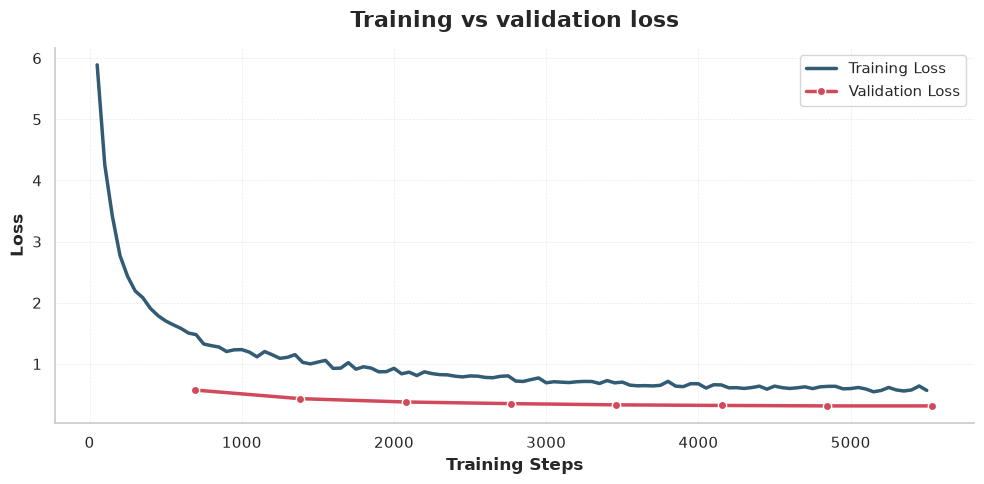

In [21]:
def plot_loss_curves(log_df: pd.DataFrame):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5))

    if "loss" in log_df.columns:
        train_loss_df = log_df.dropna(subset=["loss"])
        if not train_loss_df.empty:
            plt.plot(
                train_loss_df["step"],
                train_loss_df["loss"],
                color="#1B4965",  # deep blue
                linewidth=2.5,
                alpha=0.9,
                label="Training Loss"
            )

    if "eval_loss" in log_df.columns:
        eval_loss_df = log_df.dropna(subset=["eval_loss"])
        if not eval_loss_df.empty:
            plt.plot(
                eval_loss_df["step"],
                eval_loss_df["eval_loss"],
                color="#D1495B",  # muted red
                linewidth=2.5,
                marker="o",
                markersize=6,
                markeredgecolor="white",
                markeredgewidth=1,
                label="Validation Loss"
            )

    plt.title(
        "Training vs validation loss",
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    plt.xlabel(
        "Training Steps",
        fontsize=12,
        fontweight="semibold"
    )

    plt.ylabel(
        "Loss",
        fontsize=12,
        fontweight="semibold"
    )

    plt.legend(
        frameon=True,
        fancybox=True,
        shadow=False,
        fontsize=11,
        loc="best"
    )

    plt.grid(
        linestyle="--",
        linewidth=0.5,
        alpha=0.4
    )

    sns.despine()
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "plots" / "loss_curve.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


plot_loss_curves(log_df)

## 22. Plot validation metric curves

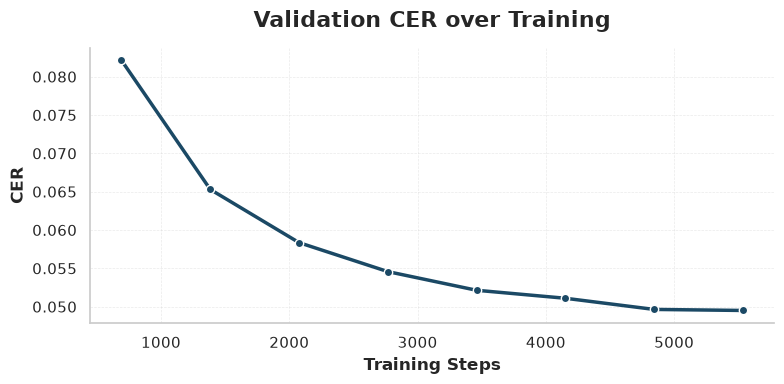

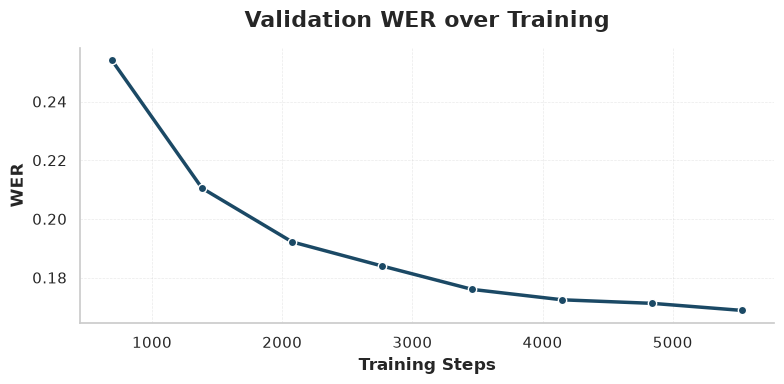

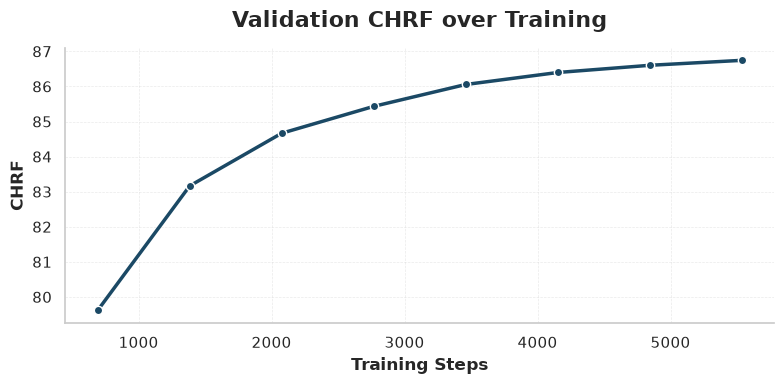

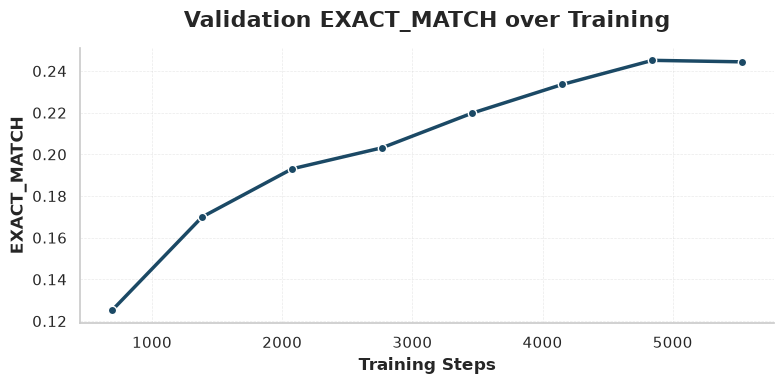

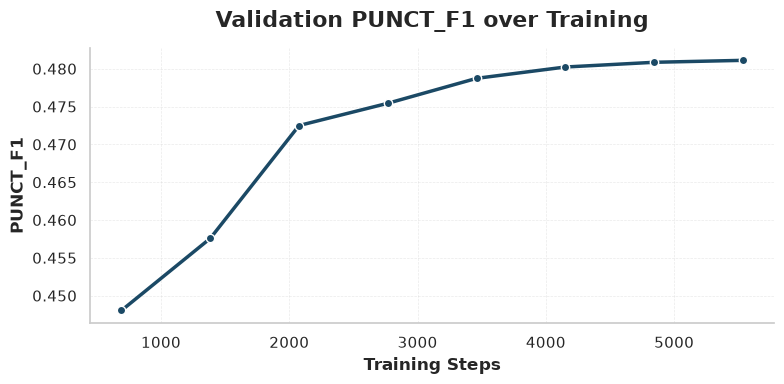

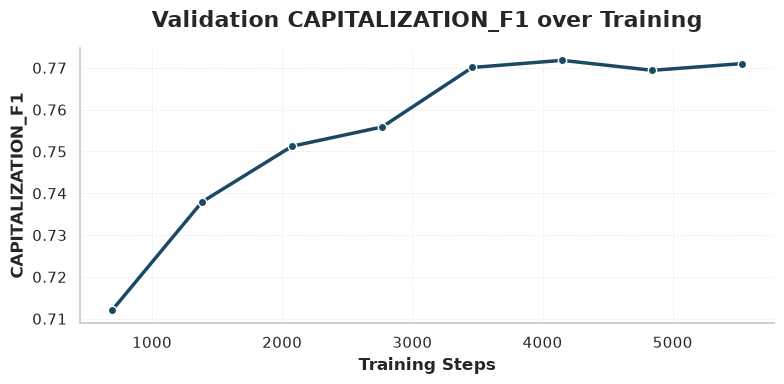

In [22]:
def plot_eval_metric(log_df: pd.DataFrame, metric_name: str):
    col = f"eval_{metric_name}"

    if col not in log_df.columns:
        print(f"Metric not found: {col}")
        return

    metric_df = log_df.dropna(subset=[col])

    if metric_df.empty:
        print(f"No values found for {col}")
        return

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 4))

    plt.plot(
        metric_df["step"],
        metric_df[col],
        color="#1B4965",  # deep blue
        linewidth=2.5,
        marker="o",
        markersize=6,
        markeredgecolor="white",
        markeredgewidth=1
    )

    plt.title(
        f"Validation {metric_name.upper()} over Training",
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    plt.xlabel(
        "Training Steps",
        fontsize=12,
        fontweight="semibold"
    )

    plt.ylabel(
        metric_name.upper(),
        fontsize=12,
        fontweight="semibold"
    )

    plt.grid(
        linestyle="--",
        linewidth=0.5,
        alpha=0.4
    )

    sns.despine()
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "plots" / f"validation_{metric_name}_curve.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


for metric in [
    "cer",
    "wer",
    "chrf",
    "exact_match",
    "punct_f1",
    "capitalization_f1"
]:
    plot_eval_metric(log_df, metric)

## 23. Generate predictions and measure inference time

In [23]:
def generate_predictions_for_df(df: pd.DataFrame, split_name: str, sample_limit=None) -> pd.DataFrame:
    model.eval()
    use_df = df.copy()
    if sample_limit is not None:
        use_df = use_df.head(sample_limit).copy()

    raw_inputs = use_df[INPUT_COL].tolist()
    inputs = [add_task_prefix(x) for x in raw_inputs]
    references = use_df[TARGET_COL].tolist()
    predictions = []

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    inference_start = time.time()

    for start in range(0, len(inputs), EVAL_BATCH_SIZE):
        batch_inputs = inputs[start:start + EVAL_BATCH_SIZE]
        encoded = tokenizer(batch_inputs, return_tensors="pt", padding=True, truncation=True, max_length=MAX_INPUT_LENGTH)
        encoded = {k: v.to(model.device) for k, v in encoded.items()}
        with torch.no_grad():
            generated_ids = model.generate(**encoded, max_length=GENERATION_MAX_LENGTH, num_beams=NUM_BEAMS)
        predictions.extend(tokenizer.batch_decode(generated_ids, skip_special_tokens=True))

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    total_seconds = time.time() - inference_start

    pred_df = pd.DataFrame({"split": split_name, "input_text": raw_inputs, "prefixed_input": inputs, "target_text": references, "prediction": predictions})
    pred_df["sentence_cer"] = [cer([r], [p]) for p, r in zip(predictions, references)]
    pred_df["sentence_wer"] = [wer([r], [p]) for p, r in zip(predictions, references)]
    pred_df["exact_match"] = [normalize_for_metric(p) == normalize_for_metric(r) for p, r in zip(predictions, references)]

    timing = {
        "split": split_name,
        "num_sentences": len(pred_df),
        "total_inference_seconds": total_seconds,
        "average_inference_seconds_per_sentence": total_seconds / len(pred_df) if len(pred_df) else None,
        "sentences_per_second": len(pred_df) / total_seconds if total_seconds > 0 else None,
    }
    pred_df.to_csv(OUTPUT_DIR / "predictions" / f"{split_name}_predictions.csv", index=False, encoding="utf-8")
    with open(OUTPUT_DIR / f"inference_time_{split_name}.json", "w", encoding="utf-8") as f:
        json.dump(timing, f, indent=2, ensure_ascii=False)
    print(json.dumps(timing, indent=2))
    return pred_df

## 24. Evaluate train, validation, and test with the same function

In [24]:
def evaluate_prediction_dataframe(pred_df: pd.DataFrame, split_name: str) -> Dict[str, Any]:
    metrics = compute_text_metrics(pred_df["prediction"].tolist(), pred_df["target_text"].tolist())
    metrics["split"] = split_name
    metrics["num_examples"] = len(pred_df)
    return metrics

train_predictions = generate_predictions_for_df(train_df, "train", sample_limit=EVAL_SAMPLE_LIMIT)
val_predictions = generate_predictions_for_df(val_df, "validation", sample_limit=EVAL_SAMPLE_LIMIT)
test_predictions = generate_predictions_for_df(test_df, "test", sample_limit=EVAL_SAMPLE_LIMIT)

metrics_train = evaluate_prediction_dataframe(train_predictions, "train")
metrics_val = evaluate_prediction_dataframe(val_predictions, "validation")
metrics_test = evaluate_prediction_dataframe(test_predictions, "test")

all_metrics = [metrics_train, metrics_val, metrics_test]
metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv(OUTPUT_DIR / "all_split_metrics.csv", index=False, encoding="utf-8")
for name, metrics in [("train", metrics_train), ("validation", metrics_val), ("test", metrics_test)]:
    with open(OUTPUT_DIR / f"metrics_{name}.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
display(metrics_df)

{
  "split": "train",
  "num_sentences": 11064,
  "total_inference_seconds": 612.8281679153442,
  "average_inference_seconds_per_sentence": 0.0553893861094852,
  "sentences_per_second": 18.054000418480072
}
{
  "split": "validation",
  "num_sentences": 1383,
  "total_inference_seconds": 77.68708825111389,
  "average_inference_seconds_per_sentence": 0.05617287653732024,
  "sentences_per_second": 17.802186066359237
}
{
  "split": "test",
  "num_sentences": 1383,
  "total_inference_seconds": 76.34363770484924,
  "average_inference_seconds_per_sentence": 0.05520147339468492,
  "sentences_per_second": 18.11545849238664
}


,cer,wer,chrf,exact_match,word_accuracy,punct_precision,punct_recall,punct_f1,punct_accuracy,capitalization_accuracy,capitalization_f1,split,num_examples
0,0.054372,0.159357,87.441864,0.261208,0.756449,0.805854,0.514034,0.592230,0.612957,0.982730,0.829314,train,11064
1,0.063823,0.185947,85.434885,0.192336,0.704126,0.729680,0.390706,0.472638,0.600760,0.977776,0.768091,validation,1383
2,0.065691,0.187663,84.940290,0.200289,0.720889,0.712966,0.361910,0.444836,0.590597,0.980003,0.797483,test,1383


## 25. Save timing summary

In [25]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

timing_summary = {
    "training": training_time_info,
    "inference_train": load_json(OUTPUT_DIR / "inference_time_train.json"),
    "inference_validation": load_json(OUTPUT_DIR / "inference_time_validation.json"),
    "inference_test": load_json(OUTPUT_DIR / "inference_time_test.json"),
}
with open(OUTPUT_DIR / "timing_summary.json", "w", encoding="utf-8") as f:
    json.dump(timing_summary, f, indent=2, ensure_ascii=False)
print(json.dumps(timing_summary, indent=2))

{
  "training": {
    "training_start_time": "2026-08-03T17:45:26.600896",
    "training_end_time": "2026-08-03T18:00:29.373422",
    "training_seconds": 902.7725229263306,
    "training_minutes": 15.046208715438842,
    "training_hours": 0.25077014525731406,
    "peak_gpu_memory_gb": 3.065178871154785
  },
  "inference_train": {
    "split": "train",
    "num_sentences": 11064,
    "total_inference_seconds": 612.8281679153442,
    "average_inference_seconds_per_sentence": 0.0553893861094852,
    "sentences_per_second": 18.054000418480072
  },
  "inference_validation": {
    "split": "validation",
    "num_sentences": 1383,
    "total_inference_seconds": 77.68708825111389,
    "average_inference_seconds_per_sentence": 0.05617287653732024,
    "sentences_per_second": 17.802186066359237
  },
  "inference_test": {
    "split": "test",
    "num_sentences": 1383,
    "total_inference_seconds": 76.34363770484924,
    "average_inference_seconds_per_sentence": 0.05520147339468492,
    "sentenc

## 26. Error category analysis

In [26]:
def has_punctuation_difference(pred: str, ref: str) -> bool:
    return get_punctuation_sequence(pred) != get_punctuation_sequence(ref)

def has_capitalization_difference(pred: str, ref: str) -> bool:
    return capitalization_labels(pred) != capitalization_labels(ref)

def has_spacing_difference(pred: str, ref: str) -> bool:
    return re.sub(r"\S", "X", pred) != re.sub(r"\S", "X", ref)

def classify_error(pred: str, ref: str) -> List[str]:
    if normalize_for_metric(pred) == normalize_for_metric(ref):
        return ["correct"]
    errors = []
    if has_punctuation_difference(pred, ref):
        errors.append("punctuation_error")
    if has_capitalization_difference(pred, ref):
        errors.append("capitalization_error")
    if has_spacing_difference(pred, ref):
        errors.append("spacing_error")
    if len(pred.split()) < len(ref.split()):
        errors.append("missing_word_error")
    if len(pred.split()) > len(ref.split()):
        errors.append("extra_word_error")
    if not errors:
        errors.append("orthographic_or_word_choice_error")
    return errors

def add_error_categories(pred_df: pd.DataFrame) -> pd.DataFrame:
    out = pred_df.copy()
    out["error_categories"] = [";".join(classify_error(p, r)) for p, r in zip(out["prediction"], out["target_text"])]
    return out

error_test_df = add_error_categories(test_predictions)
error_test_df.to_csv(OUTPUT_DIR / "analysis" / "test_error_categories.csv", index=False, encoding="utf-8")
error_counts = error_test_df["error_categories"].str.split(";").explode().value_counts().reset_index()
error_counts.columns = ["error_category", "count"]
error_counts.to_csv(OUTPUT_DIR / "analysis" / "test_error_category_counts.csv", index=False, encoding="utf-8")
display(error_counts)

,error_category,count
0,spacing_error,1006
1,capitalization_error,811
2,punctuation_error,701
3,correct,277
4,missing_word_error,226
5,extra_word_error,93
6,orthographic_or_word_choice_error,33


## 27. Plot error categories

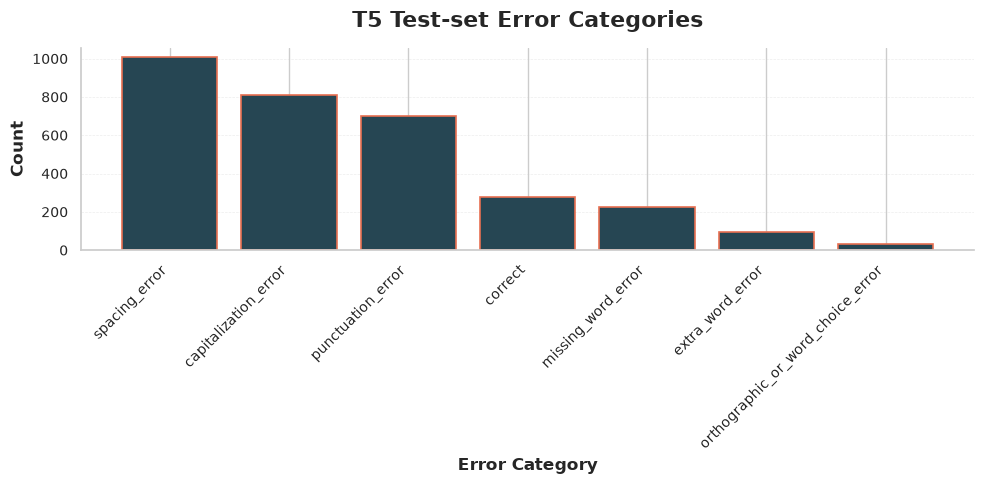

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional journal-style theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Colors
bar_color = "#264653"
edge_color = "#E76F51"

# Bar chart
plt.bar(
    error_counts["error_category"],
    error_counts["count"],
    color=bar_color,
    edgecolor=edge_color,
    linewidth=1.2
)

# Title and labels
plt.title(
    "T5 Test-set Error Categories",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Error Category",
    fontsize=12,
    fontweight="semibold"
)

plt.ylabel(
    "Count",
    fontsize=12,
    fontweight="semibold"
)

# Tick styling
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

# Grid styling
plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.35
)

# Remove top and right borders
sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    OUTPUT_DIR / "plots" / "test_error_categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 28. Best and worst predictions

In [28]:
best_predictions = error_test_df.sort_values(["sentence_cer", "sentence_wer"], ascending=True).head(20)
worst_predictions = error_test_df.sort_values(["sentence_cer", "sentence_wer"], ascending=False).head(20)
best_predictions.to_csv(OUTPUT_DIR / "analysis" / "top_20_best_predictions.csv", index=False, encoding="utf-8")
worst_predictions.to_csv(OUTPUT_DIR / "analysis" / "top_20_worst_predictions.csv", index=False, encoding="utf-8")
print("Best predictions")
display(best_predictions[["input_text", "target_text", "prediction", "sentence_cer", "sentence_wer", "error_categories"]])
print("Worst predictions")
display(worst_predictions[["input_text", "target_text", "prediction", "sentence_cer", "sentence_wer", "error_categories"]])

Best predictions


,input_text,target_text,prediction,sentence_cer,sentence_wer,error_categories
11,Meme Pas dans envelope?,Mem pas dans envelope?,Mem pas dans envelope?,0.0,0.0,correct
15,Li fer client fume bred mourom saaa,Li fer client fume bred mourom sa.,Li fer client fume bred mourom sa.,0.0,0.0,correct
20,Linn roder linn ggner.....,Linn rode linn gagne.....,Linn rode linn gagne.....,0.0,0.0,correct
32,[NAME] einn?? Ki pou fer???,[NAME] ein?? Ki pu fer???,[NAME] ein?? Ki pu fer???,0.0,0.0,correct
34,Ki rôle mama la?,Ki rôle mama la?,Ki rôle mama la?,0.0,0.0,correct
38,Ena so cotée pervers ladan. Devek in fair kroi...,Ena so kote pervers ladan. Devek inn fer krwar...,Ena so kote pervers ladan. Devek inn fer krwar...,0.0,0.0,correct
41,"[NAME], to kone ki la boutique sa","[NAME], to kone ki la boutique sa?","[NAME], to kone ki la boutique sa?",0.0,0.0,correct
44,9 ans apres? Tight. Scénario peut être monter ...,9 ans apre? Tight. Scénario peut être monte pi...,9 ans apre? Tight. Scénario peut être monte pi...,0.0,0.0,correct
51,Ena le rat et mangoose si là-bas,Ena le rat et mangoose si là-bas.,Ena le rat et mangoose si là-bas.,0.0,0.0,correct
53,Espere li pa gn lagard de l'enfant,Espere li pa gagne lagard de l'enfant.,Espere li pa gagne lagard de l'enfant.,0.0,0.0,correct


Worst predictions


,input_text,target_text,prediction,sentence_cer,sentence_wer,error_categories
967,𝑭𝒊𝒏𝒊 𝒕𝒊𝒓𝒆́ 𝒔𝒂 𝒏𝒐 𝒘𝒂𝒓𝒏𝒊𝒏𝒈 𝒛𝒕 𝒆𝒏𝒓𝒆𝒕𝒂𝒓𝒅🤣🤣🤣🤣,"𝑭𝒊𝒏𝒊 𝒕𝒊𝒓𝒆e 𝒔𝒂 𝒏𝒐 𝒘𝒂𝒓𝒏𝒊𝒏𝒈, 𝒛o𝒕 𝒆𝒏𝒓𝒆𝒕𝒂𝒓𝒅.🤣🤣🤣🤣",Fini tire sa no warning zot enretard.,0.790698,1.000000,punctuation_error;capitalization_error;spacing...
641,Ah la vie 🤣🤣🤣🤣🤣🤣🤣,Ah lavi! 🤣🤣🤣🤣🤣🤣🤣,Ah lavi.,0.562500,0.666667,punctuation_error;spacing_error;missing_word_e...
426,Misie minis al laba en casiet san journalis pa...,"Misye minis, ale laba en kasyet san journalis,...",Misie minis ale laba. En kasyet san journalis ...,0.454776,0.599119,punctuation_error;capitalization_error;spacing...
1250,Sa oci ena!!!! 😱😱😱😱 🤦🏻‍♀️,Sa osi ena!!!! 😱😱😱😱 🤦🏻‍♀️,Sa osi ena!!!!,0.440000,0.400000,spacing_error;missing_word_error
958,Banla oo pardon🤦🏾‍♂️🤦🏾‍♂️,Banla oo pardon🤦🏾‍♂️🤦🏾‍♂️.,Banla ou pardon.,0.423077,0.666667,spacing_error
649,Eta nonnn😭😂😂😂,Eta non!😭😂😂😂,Eta non.,0.416667,0.500000,punctuation_error;spacing_error
234,Double decker in fire 🔥🔥🔥🔥🔥🚍🚍🚍🚌🚌♨️♨️,Double decker inn fire. 🔥🔥🔥🔥🔥🚍🚍🚍🚌🚌♨️♨️,Double decker inn fire.,0.394737,0.200000,spacing_error;missing_word_error
150,ENA DIMOUNE DÉGUEULASSE💩💩💩💩💩🤡 🤮🤮🤮🤮,ENA DIMUNN DÉGUEULASSE.💩💩💩💩💩🤡 🤮🤮🤮🤮,ENA DIMOUNE DÉGUEULASSE.,0.382353,0.750000,capitalization_error;spacing_error;missing_wor...
1241,"[NAME], diferrr 🤣🤣🤣🤣🤣🤣🤣","[NAME], dife. 🤣🤣🤣🤣🤣🤣🤣","[NAME], dife.",0.380952,0.333333,spacing_error;missing_word_error
232,🤦‍♀️🤦‍♀️🤦‍♀️ artistes cot p aller!!!!🙄,🤦‍♀️🤦‍♀️🤦‍♀️ artistes kot pe ale!!!!🙄,artistes kot pe ale!!!!,0.378378,0.400000,spacing_error;missing_word_error


## 29. Orthographic variation recovery analysis

Edit `ORTHOGRAPHIC_VARIANTS` with variants from your Mauritian Creole corpus.

In [29]:
ORTHOGRAPHIC_VARIANTS = {
    # "informal_variant": "target_standard_form"
    "mwa": "mo",
    "twa": "to",
    "kiii": "ki",
}

def variant_recovery_analysis(pred_df: pd.DataFrame, variants: Dict[str, str]) -> pd.DataFrame:
    rows = []
    for variant, target_form in variants.items():
        subset = pred_df[pred_df["input_text"].str.contains(rf"\b{re.escape(variant)}\b", case=False, regex=True, na=False)].copy()
        if subset.empty:
            rows.append({"variant": variant, "target_form": target_form, "num_cases": 0, "num_recovered": 0, "recovery_rate": None})
            continue
        recovered = subset["prediction"].str.contains(rf"\b{re.escape(target_form)}\b", case=False, regex=True, na=False)
        rows.append({"variant": variant, "target_form": target_form, "num_cases": int(len(subset)), "num_recovered": int(recovered.sum()), "recovery_rate": float(recovered.mean())})
    return pd.DataFrame(rows)

variant_df = variant_recovery_analysis(test_predictions, ORTHOGRAPHIC_VARIANTS)
variant_df.to_csv(OUTPUT_DIR / "analysis" / "orthographic_variant_recovery_test.csv", index=False, encoding="utf-8")
display(variant_df)

,variant,target_form,num_cases,num_recovered,recovery_rate
0,mwa,mo,3,3,1.0
1,twa,to,10,2,0.2
2,kiii,ki,0,0,NaN


## 30. Emoji and symbol subset analysis

In [30]:
EMOJI_SYMBOL_PATTERN = re.compile(
    "["
    "\U0001F300-\U0001F5FF"
    "\U0001F600-\U0001F64F"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\u2600-\u26FF"
    "\u2700-\u27BF"
    "]+",
    flags=re.UNICODE,
)

def contains_emoji_or_symbol(text: str) -> bool:
    return bool(EMOJI_SYMBOL_PATTERN.search(str(text)))

def subset_metric_analysis(pred_df: pd.DataFrame, condition_col: str) -> pd.DataFrame:
    rows = []
    for value, subset in pred_df.groupby(condition_col):
        metrics = compute_text_metrics(subset["prediction"].tolist(), subset["target_text"].tolist())
        metrics[condition_col] = value
        metrics["num_examples"] = len(subset)
        rows.append(metrics)
    return pd.DataFrame(rows)

test_predictions_with_emoji = test_predictions.copy()
test_predictions_with_emoji["has_emoji_or_symbol"] = test_predictions_with_emoji["input_text"].apply(contains_emoji_or_symbol)
emoji_metrics_df = subset_metric_analysis(test_predictions_with_emoji, "has_emoji_or_symbol")
emoji_metrics_df.to_csv(OUTPUT_DIR / "analysis" / "emoji_symbol_subset_metrics_test.csv", index=False, encoding="utf-8")
display(emoji_metrics_df)

,cer,wer,chrf,exact_match,word_accuracy,punct_precision,punct_recall,punct_f1,punct_accuracy,capitalization_accuracy,capitalization_f1,has_emoji_or_symbol,num_examples
0,0.058600,0.176610,85.785334,0.251133,0.744448,0.708293,0.362081,0.445476,0.595663,0.979860,0.795025,False,1103
1,0.095932,0.234676,81.277296,0.000000,0.620291,0.564000,0.348150,0.424267,0.568207,0.980639,0.808159,True,280


## 31. Synthetic noise robustness analysis

This creates a controlled noisy version of the test set. Use it as an additional robustness test, not as the main test-set result.

In [31]:
def add_repeated_letter_noise(text: str, probability: float = 0.08) -> str:
    out = []
    for ch in str(text):
        out.append(ch)
        if ch.isalpha() and random.random() < probability:
            out.append(ch * random.choice([1, 2]))
    return "".join(out)

def remove_random_punctuation(text: str, probability: float = 0.5) -> str:
    out = []
    for ch in str(text):
        if ch in PUNCTUATION_MARKS and random.random() < probability:
            continue
        out.append(ch)
    return "".join(out)

def create_noisy_test_set(df: pd.DataFrame) -> pd.DataFrame:
    noisy = df.copy()
    noisy[INPUT_COL] = noisy[INPUT_COL].apply(add_repeated_letter_noise).apply(remove_random_punctuation)
    return noisy

noisy_test_df = create_noisy_test_set(test_df)
noisy_test_df.to_csv(OUTPUT_DIR / "analysis" / "synthetic_noisy_test_inputs.csv", index=False, encoding="utf-8")
noisy_test_predictions = generate_predictions_for_df(noisy_test_df, "test_synthetic_noisy", sample_limit=EVAL_SAMPLE_LIMIT)
noisy_test_metrics = evaluate_prediction_dataframe(noisy_test_predictions, "test_synthetic_noisy")
with open(OUTPUT_DIR / "metrics_test_synthetic_noisy.json", "w", encoding="utf-8") as f:
    json.dump(noisy_test_metrics, f, indent=2, ensure_ascii=False)
display(pd.DataFrame([metrics_test, noisy_test_metrics]))

{
  "split": "test_synthetic_noisy",
  "num_sentences": 1383,
  "total_inference_seconds": 85.35707950592041,
  "average_inference_seconds_per_sentence": 0.06171878489220565,
  "sentences_per_second": 16.20252248560208
}


,cer,wer,chrf,exact_match,word_accuracy,punct_precision,punct_recall,punct_f1,punct_accuracy,capitalization_accuracy,capitalization_f1,split,num_examples
0,0.065691,0.187663,84.94029,0.200289,0.720889,0.712966,0.361910,0.444836,0.590597,0.980003,0.797483,test,1383
1,0.155262,0.371002,70.01685,0.052784,0.505534,0.552860,0.202359,0.274063,0.393347,0.964257,0.645873,test_synthetic_noisy,1383


## 32. Final T5 experiment summary table

In [32]:
summary_rows = []
for metrics in all_metrics:
    row = metrics.copy()
    row["model"] = "T5"
    row["model_name"] = MODEL_NAME
    row["task_prefix"] = TASK_PREFIX
    row["training_minutes"] = training_time_info["training_minutes"]
    row["peak_gpu_memory_gb"] = training_time_info["peak_gpu_memory_gb"]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_cols = ["model", "model_name", "task_prefix", "split", "num_examples", "cer", "wer", "chrf", "exact_match", "word_accuracy", "punct_f1", "capitalization_f1", "training_minutes", "peak_gpu_memory_gb"]
summary_df = summary_df[[c for c in summary_cols if c in summary_df.columns]]
summary_df.to_csv(OUTPUT_DIR / "t5_experiment_summary.csv", index=False, encoding="utf-8")
display(summary_df)

,model,model_name,task_prefix,split,num_examples,cer,wer,chrf,exact_match,word_accuracy,punct_f1,capitalization_f1,training_minutes,peak_gpu_memory_gb
0,T5,google-t5/t5-small,restore Mauritian Creole text:,train,11064,0.054372,0.159357,87.441864,0.261208,0.756449,0.592230,0.829314,15.046209,3.065179
1,T5,google-t5/t5-small,restore Mauritian Creole text:,validation,1383,0.063823,0.185947,85.434885,0.192336,0.704126,0.472638,0.768091,15.046209,3.065179
2,T5,google-t5/t5-small,restore Mauritian Creole text:,test,1383,0.065691,0.187663,84.940290,0.200289,0.720889,0.444836,0.797483,15.046209,3.065179


## 33. What each output is for

### Main model performance
- `all_split_metrics.csv`
- `t5_experiment_summary.csv`

### Runtime analysis
- `training_time.json`
- `timing_summary.json`

### Overfitting analysis
- `plots/loss_curve.png`
- `plots/validation_cer_curve.png`
- `plots/validation_wer_curve.png`
- `plots/validation_chrf_curve.png`

### T5-specific tokenization analysis
- `analysis/t5_token_summary.csv`
- `analysis/t5_token_features_all_splits.csv`
- `analysis/t5_tokenization_examples.csv`
- `analysis/t5_top_50_input_tokens.csv`
- `plots/t5_input_token_length_distribution.png`

### Error analysis
- `analysis/test_error_category_counts.csv`
- `analysis/top_20_best_predictions.csv`
- `analysis/top_20_worst_predictions.csv`

### Orthographic variation analysis
- `analysis/orthographic_variant_recovery_test.csv`

### Emoji/noise analysis
- `analysis/emoji_symbol_subset_metrics_test.csv`
- `metrics_test_synthetic_noisy.json`

## 34. Notes for final comparison notebook

Later, the final comparison notebook can load:

```text
results/byt5/byt5_experiment_summary.csv
results/t5/t5_experiment_summary.csv
results/qwen/qwen_experiment_summary.csv
results/bilstm/bilstm_experiment_summary.csv
```

Then it can create one combined model comparison table and graphs for:

- CER
- WER
- chrF
- Exact Match
- Word Accuracy
- Punctuation F1
- Capitalization F1
- Training time
- Inference time
- GPU memory

## 35. References to discuss in the thesis

- T5: *Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer*.
- Hugging Face Transformers T5 documentation.
- SentencePiece-style tokenization/subword analysis.

Use your university's required citation style in the final thesis document.